In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Simular el salario anual de 1000 actuarios y si consigue empleo al ginalizar un año de egreso
#Parámetros 
media = 132000
var = 4000
p = 0.7 #proporcion de actuarios que consiguen empleo en un año 
n = 1000
#Generar nuestros datos
np.random.seed(0)
salario = np.random.normal(loc = media, scale = np.sqrt(var), size = n)
empleo_anio = np.random.choice(["Si","No"], p = [p, 1-p], size = n)

#Creamos dataframe
datos = dict(salario = salario, empleo = empleo_anio)
actuarios = pd.DataFrame(datos)
actuarios.head()

,salario,empleo
0,132111.568467,No
1,132025.308164,No
2,132061.900825,No
3,132141.726530,No
4,132118.114738,No


In [3]:
#Elegimos una muestra de tamaño 30
actuarios["salario"].mean() #hacemos la media de la columna salario, todo esto se puede con la libreria pandas 

131997.13771449862

In [4]:
conteo = actuarios.groupby("empleo").count().reset_index() #Hace el conteo de cuantos si y cuantos no tiene la variable columna
conteo["conteo"] = conteo["salario"]
conteo = conteo.drop("salario", axis = 1)
conteo["proporcion"] = conteo["conteo"]/len(actuarios)
conteo["%"] = conteo["proporcion"]*100
conteo

,empleo,conteo,proporcion,%
0,No,326,0.326,32.6
1,Si,674,0.674,67.4


In [5]:
len(actuarios)
import math 
math.comb(1000,30) #Hace todas las combinaciones posibles de muestras, de que de los mil actuarios, tome 30 

2429608192173745103270389838576750719302222606198631438800

In [6]:
#Muestreo aleatorio simple
import random
muestra = actuarios.sample(n=30).reset_index()#Son las diferentes muestras que se pueden generar 

In [7]:
#Calcular estadísticos muestrales 
mean_sample = muestra["salario"].mean() # media muestral
mean_sample

132004.1273558709

In [8]:
var_sample = muestra["salario"].var() #varianza muestral
var_sample

3372.379172923902

In [9]:
p_sample = len(muestra[muestra["empleo"] == "Si"])/30 #quiero que de la muestra solo me filtre los datos que tiene si, y que me de la longitud
p_sample

0.6333333333333333

In [10]:
psample = []
meansample = []
for i in range(1000):
    muestra = actuarios.sample(n=100).reset_index() #generamos una muestra de tamaño n
    mean_sample = muestra["salario"].mean() #media muestral
    p_sample = len(muestra[muestra["empleo"] == "Si"])/100
    psample.append(p_sample)
    meansample.append(mean_sample)

In [11]:
sample = dict(psample = psample, meansample = meansample)
sample_df = pd.DataFrame(sample)

In [12]:
import matplotlib.pyplot as plt

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


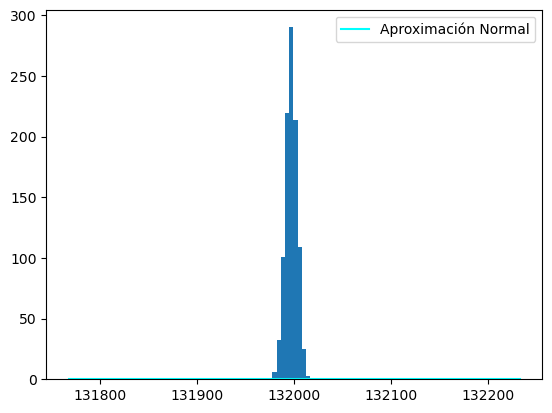

In [13]:
plt.hist(sample_df["meansample"])
plt.legend()

####

# Para graficar la normal 
from scipy.stats import norm
mu = mean_sample
sigma = np.sqrt(var_sample)


# Rango de valores x para la PDF normal
x = np.linspace(mean_sample - 4 * sigma, mean_sample + 4 * sigma, 1000)


# Calcular la PDF de la normal
pdf = norm.pdf(x, mean_sample, sigma)

# Graficar la PDF
plt.plot(x, pdf, label='Aproximación Normal', color='cyan')

# Línea vertical en la media
plt.vlines(mean_sample, ymin=0, ymax=max(pdf), color='black', linestyles=':', alpha=0.8)

# Mostrar leyenda y gráfico
plt.legend()
plt.show()


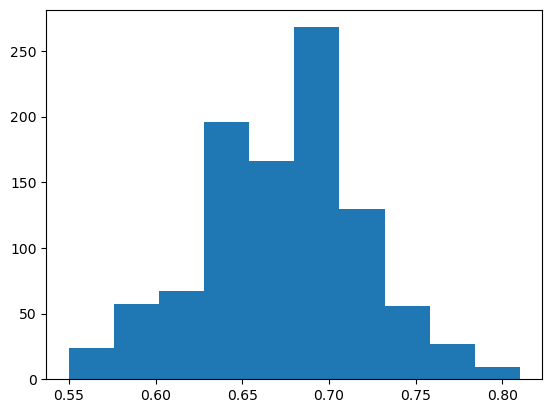

In [14]:
plt.hist(sample_df["psample"])

m = p
v =( p * (1-p))/n


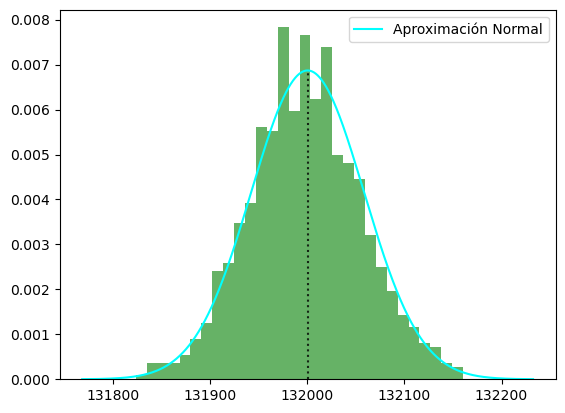

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Valores proporcionados
sigma = np.sqrt(var_sample)

# Simulación de datos de muestra alrededor de la media y varianza dadas
np.random.seed(0)
sample_df = {"meansample": np.random.normal(mean_sample, sigma, 1000)}

# Graficar el histograma
plt.hist(sample_df["meansample"], bins=30, density=True, alpha=0.6, color='g')
plt.legend(["Histograma de muestras"])

# Rango de valores x para la PDF normal
x = np.linspace(mean_sample - 4 * sigma, mean_sample + 4 * sigma, 1000)


# Calcular la PDF de la normal
pdf = norm.pdf(x, mean_sample, sigma)

# Graficar la PDF
plt.plot(x, pdf, label='Aproximación Normal', color='cyan')

# Línea vertical en la media
plt.vlines(mean_sample, ymin=0, ymax=max(pdf), color='black', linestyles=':', alpha=0.8)

# Mostrar leyenda y gráfico
plt.legend()
plt.show()
